# Partie 1 - Analyse Exploratoire des Donnees

Ce notebook repart du dataset actuel et documente l'exploration initiale des donnees RH : structure, qualite, variables disponibles, premiers signaux sur l'attrition et points de vigilance pour la suite du projet.


In [1]:
from pathlib import Path
import importlib
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "raw").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import hr_analysis_utils as utils
importlib.reload(utils)

MahalanobisAnomalyDetector = utils.MahalanobisAnomalyDetector
random_oversample_minority = utils.random_oversample_minority
SimpleLogisticRegression = utils.SimpleLogisticRegression
attrition_by_group = utils.attrition_by_group
attrition_gap_summary = utils.attrition_gap_summary
coefficient_importance = utils.coefficient_importance
correlation_with_attrition = utils.correlation_with_attrition
dataset_overview = utils.dataset_overview
kpi_table = utils.kpi_table
load_data = utils.load_data
add_derived_columns = utils.add_derived_columns
missing_summary = utils.missing_summary
numeric_summary = utils.numeric_summary
plot_bar = utils.plot_bar
plot_box_by_attrition = utils.plot_box_by_attrition
plot_correlation_heatmap = utils.plot_correlation_heatmap
plot_histogram = utils.plot_histogram
plot_top_coefficients = utils.plot_top_coefficients
prepare_model_data = utils.prepare_model_data
prepare_numeric_anomaly_data = utils.prepare_numeric_anomaly_data
pr_auc_score_manual = utils.pr_auc_score_manual
roc_auc_score_manual = utils.roc_auc_score_manual
salary_gap_by_gender = utils.salary_gap_by_gender
average_by_group = utils.average_by_group
top_attrition_segments = utils.top_attrition_segments
find_best_threshold = utils.find_best_threshold
classification_metrics = utils.classification_metrics

DATA_PATH = PROJECT_ROOT / "raw" / "people_analytics_dataset.csv"
raw_df = pd.read_csv(DATA_PATH)
duplicate_employee_ids = int(raw_df["employee_id"].duplicated().sum()) if "employee_id" in raw_df.columns else 0
source_row_count = len(raw_df)
df = add_derived_columns(raw_df.drop_duplicates(subset=["employee_id"]).copy())
clean_row_count = len(df)
pd.set_option("display.max_columns", 100)


## 1. Chargement et vue d'ensemble

On commence par verifier la taille du dataset, le taux d'attrition et les principaux points de qualite de donnees.


In [2]:
dataset_overview(df)


,Indicateur,Valeur
0,Nombre de lignes,8000.00
1,Variables sources,28.00
2,Variables ajoutees,6.00
3,Taux d'attrition (%),18.77
4,Cellules manquantes (source),480.00
5,employee_id dupliques,0.00


In [3]:
pd.DataFrame(
    [
        ("Lignes source", source_row_count),
        ("Lignes apres dedoublonnage employee_id", clean_row_count),
        ("Doublons employee_id supprimes", duplicate_employee_ids),
    ],
    columns=["Controle", "Valeur"],
)


,Controle,Valeur
0,Lignes source,8020
1,Lignes apres dedoublonnage employee_id,8000
2,Doublons employee_id supprimes,20


In [4]:
df.head()


,employee_id,age,gender,country,department,job_role,education_level,school_tier,parental_status,accented_name_flag,contracted_hours_weekly,years_at_company,manager_level,remote_ratio,performance_rating,engagement_score,training_hours,internal_mobility_count,promotion_last_3y,absenteeism_days,overtime_hours,manager_favoritism_score,visibility_score,psychological_safety_score,salary,bonus,stock_options,attrition,age_group,remote_band,engagement_band,overtime_band,absence_band,salary_quartile
0,EMP_100000,25,Male,Canada,Data,Data Scientist,Master,Tier 2,Parent,0,35,4,0,0,3.07,76.138401,26,0,0,15,3,59.4,61.9,52.1,59751.0,543,4396,0,<30,0%,High,0-5,11+,Q2
1,EMP_100001,33,Female,Germany,Sales,Sales Executive,Bachelor,Tier 3,Parent,1,28,3,0,25,3.48,72.365510,23,1,0,27,3,58.1,50.6,39.7,58502.0,6895,514,0,30-39,25%,High,0-5,11+,Q2
2,EMP_100002,34,Male,France,HR,Talent Manager,Master,Tier 2,No Children,0,28,4,0,25,3.81,81.316227,51,0,0,25,3,76.0,64.8,44.8,57278.0,1887,2504,0,30-39,25%,Very High,0-5,11+,Q2
3,EMP_100003,38,Male,France,Data,Data Engineer,Master,Tier 2,No Children,0,28,10,0,75,3.96,69.305706,29,0,0,20,25,79.8,54.6,33.2,72989.0,8585,986,1,30-39,75%,Medium,16-25,11+,Q4
4,EMP_100004,36,Male,Germany,IT,DevOps Engineer,Bachelor,Tier 1,No Children,0,35,10,1,100,1.84,73.182769,27,0,1,9,27,38.8,52.5,68.6,81888.0,1530,1782,0,30-39,100%,High,26+,6-10,Q4


## 2. Variables et qualite de donnees

Le CSV reel contient 28 variables source. Par rapport a l'enonce initial, deux variables meritent une attention particuliere :

- `years_at_company`, utile pour analyser l'anciennete et la retention
- `accented_name_flag`, variable sensible a traiter avec prudence d'un point de vue ethique

Le champ `salary_band` n'est pas present dans le fichier.


In [5]:
missing_summary(df)


,missing_count,missing_pct,dtype
performance_rating,160,2.0,float64
engagement_score,160,2.0,float64
salary,160,2.0,float64


In [6]:
numeric_summary(df).head(15)


,mean,std,min,25%,50%,75%,max
age,35.78,8.43,22.0,30.00,36.00,42.00,63.0
accented_name_flag,0.20,0.40,0.0,0.00,0.00,0.00,1.0
contracted_hours_weekly,32.99,3.17,28.0,28.00,35.00,35.00,35.0
years_at_company,4.99,4.06,0.0,1.00,5.00,8.00,24.0
manager_level,0.51,0.80,0.0,0.00,0.00,1.00,3.0
remote_ratio,51.20,31.22,0.0,25.00,50.00,75.00,100.0
performance_rating,3.45,0.70,1.0,2.98,3.46,3.93,5.0
engagement_score,67.79,14.74,20.0,58.00,67.75,78.04,100.0
training_hours,34.47,17.37,0.0,22.00,34.00,46.00,96.0
internal_mobility_count,0.98,1.00,0.0,0.00,1.00,2.00,7.0


In [7]:
display(attrition_by_group(df, "accented_name_flag", ascending=False))

years_at_company_quartile = pd.qcut(df["years_at_company"], 4, duplicates="drop")
(df.groupby(years_at_company_quartile, observed=False)["attrition"].mean() * 100).round(2)


,accented_name_flag,effectif,departs,attrition_rate_pct
1,1,1594,318,19.95
0,0,6406,1184,18.48


years_at_company
(-0.001, 1.0]    21.13
(1.0, 5.0]       18.84
(5.0, 8.0]       17.73
(8.0, 24.0]      16.64
Name: attrition, dtype: float64

## 3. Distribution de la cible

L'attrition represente environ **18,8 %** des effectifs apres dedoublonnage. La classe positive reste minoritaire, mais le niveau de desequilibre est compatible avec une analyse supervisee exploitable.


In [8]:
attrition_table = attrition_by_group(df, "attrition", ascending=True)
attrition_table


,attrition,effectif,departs,attrition_rate_pct
0,0,6498,0,0.0
1,1,1502,1502,100.0


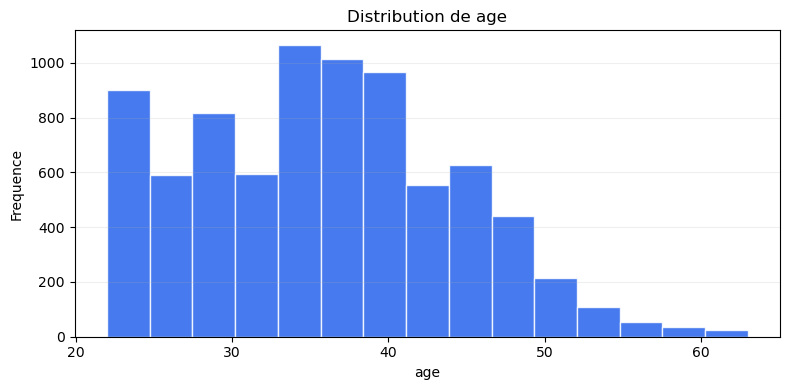

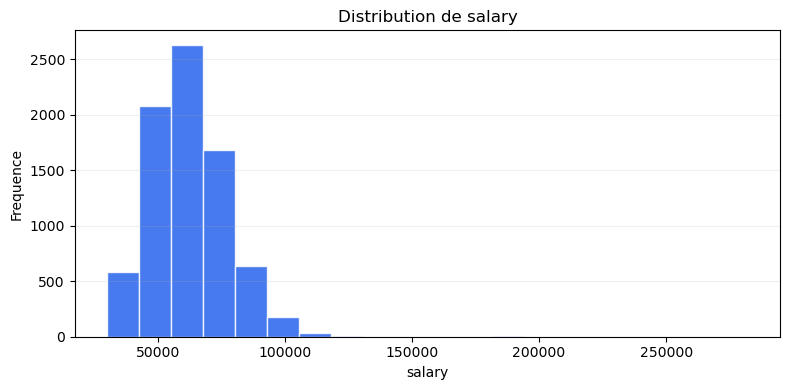

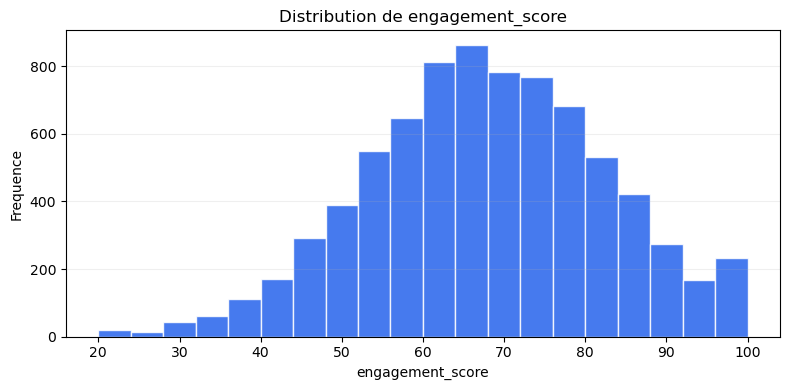

In [9]:
plot_histogram(df, "age", bins=15)
plot_histogram(df, "salary", bins=20)
plot_histogram(df, "engagement_score", bins=20)


## 4. Premiers signaux par segment

Cette section cherche a identifier les segments ou le turnover semble plus eleve, avant toute modelisation.


In [10]:
attrition_department = attrition_by_group(df, "department")
attrition_country = attrition_by_group(df, "country")
attrition_remote = attrition_by_group(df, "remote_band", ascending=True)
top_segments = top_attrition_segments(df, ["department", "country"], min_count=120, top_n=10)

display(attrition_department)
display(attrition_country)
display(attrition_remote)
display(top_segments)


,department,effectif,departs,attrition_rate_pct
3,HR,1033,222,21.49
2,Finance,946,195,20.61
7,Sales,1001,200,19.98
0,Customer Support,1024,194,18.95
1,Data,1039,187,18.00
4,IT,969,170,17.54
5,Marketing,972,170,17.49
6,Operations,1016,164,16.14


,country,effectif,departs,attrition_rate_pct
3,Spain,1279,257,20.09
1,France,1337,262,19.60
4,UK,1337,251,18.77
5,USA,1343,249,18.54
2,Germany,1352,244,18.05
0,Canada,1352,239,17.68


,remote_band,effectif,departs,attrition_rate_pct
0,0%,1221,211,17.28
4,75%,1552,283,18.23
1,100%,1221,228,18.67
2,25%,1169,225,19.25
3,50%,2837,555,19.56


,department,country,effectif,attrition_rate_pct,engagement_mean
21,HR,Spain,169,26.04,68.99
13,Finance,France,137,25.55,67.36
42,Sales,Canada,172,23.84,64.89
1,Customer Support,France,186,23.12,67.71
25,IT,France,162,22.84,66.66
14,Finance,Germany,163,22.09,67.16
45,Sales,Spain,141,21.99,67.30
23,HR,USA,178,21.91,67.06
35,Marketing,USA,161,21.74,68.55
9,Data,Spain,152,21.71,68.51


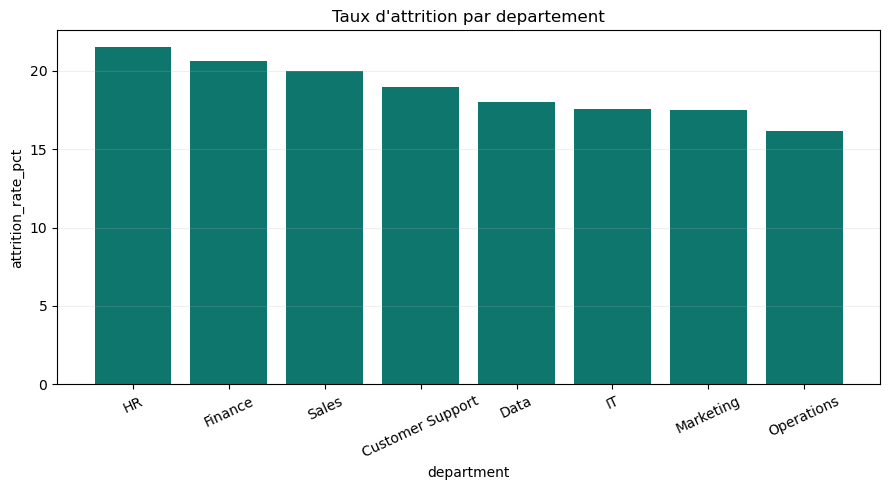

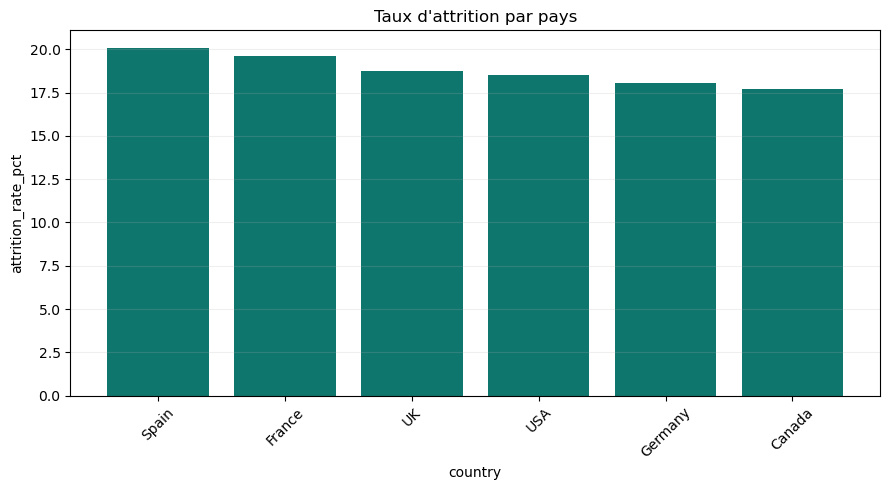

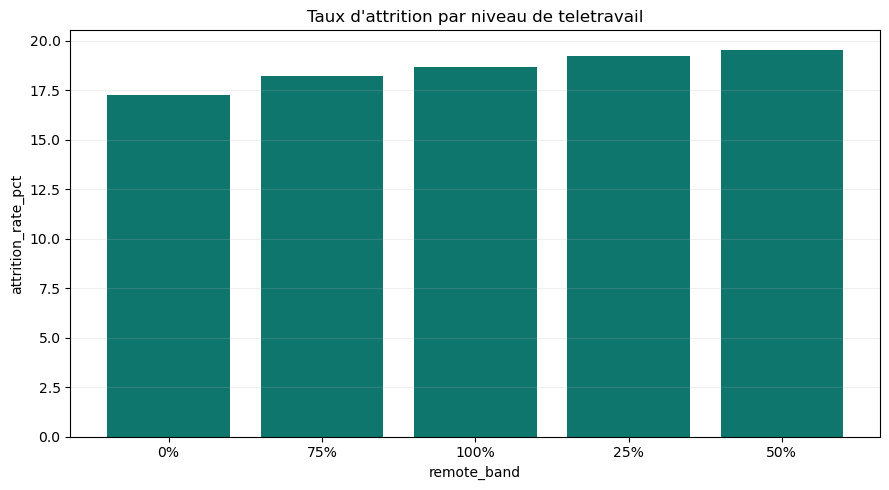

In [11]:
plot_bar(attrition_department, "department", "attrition_rate_pct", title="Taux d'attrition par departement", rotation=25)
plot_bar(attrition_country, "country", "attrition_rate_pct", title="Taux d'attrition par pays")
plot_bar(attrition_remote, "remote_band", "attrition_rate_pct", title="Taux d'attrition par niveau de teletravail", rotation=0)


## 5. Variables numeriques et attrition

On compare ensuite plusieurs dimensions RH entre les collaborateurs restes et ceux ayant quitte l'entreprise.


In [12]:
attrition_gap_summary(df)


,depart_mean,reste_mean,ecart_depart_moins_reste
engagement_score,66.55,68.08,-1.53
psychological_safety_score,44.13,55.94,-11.81
overtime_hours,23.15,20.57,2.58
absenteeism_days,21.02,12.23,8.79
training_hours,33.95,34.59,-0.64
salary,61096.34,62594.44,-1498.09
visibility_score,64.76,64.82,-0.06
manager_favoritism_score,59.41,60.86,-1.44
years_at_company,4.60,5.07,-0.47
internal_mobility_count,0.48,1.09,-0.61


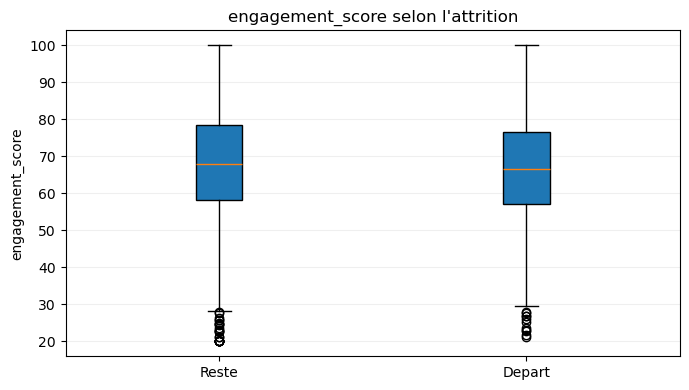

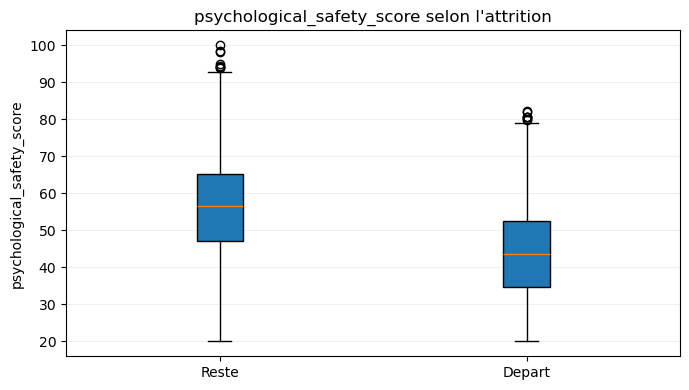

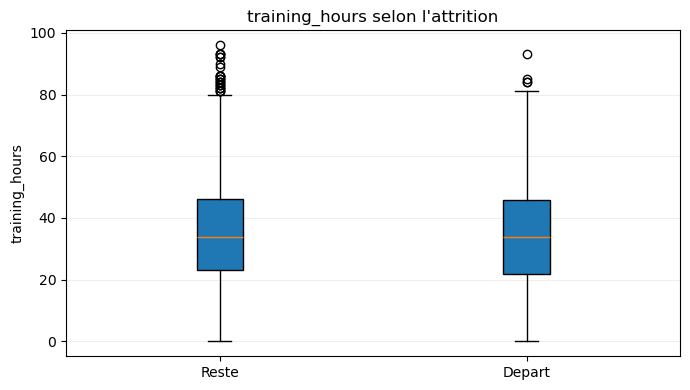

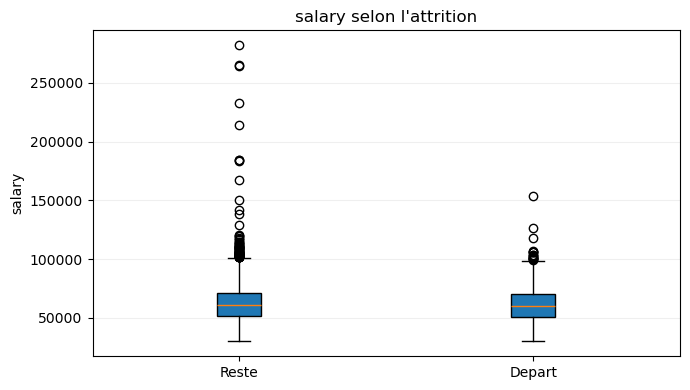

In [13]:
plot_box_by_attrition(df, "engagement_score")
plot_box_by_attrition(df, "psychological_safety_score")
plot_box_by_attrition(df, "training_hours")
plot_box_by_attrition(df, "salary")


In [14]:
correlation_with_attrition(df)


attrition                     1.000
absenteeism_days              0.441
overtime_hours                0.086
accented_name_flag            0.015
performance_rating            0.011
remote_ratio                  0.005
stock_options                 0.004
manager_level                 0.001
visibility_score             -0.002
training_hours               -0.014
age                          -0.017
bonus                        -0.027
salary                       -0.037
engagement_score             -0.040
years_at_company             -0.045
manager_favoritism_score     -0.052
promotion_last_3y            -0.148
internal_mobility_count      -0.238
contracted_hours_weekly      -0.302
psychological_safety_score   -0.326
Name: attrition, dtype: float64

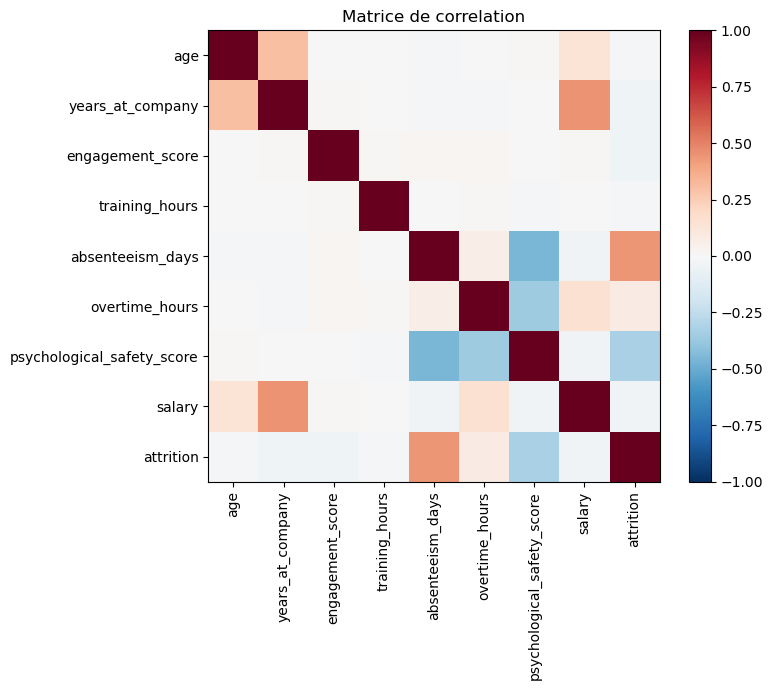

In [15]:
plot_correlation_heatmap(
    df,
    columns=[
        "age",
        "years_at_company",
        "engagement_score",
        "training_hours",
        "absenteeism_days",
        "overtime_hours",
        "psychological_safety_score",
        "salary",
        "attrition",
    ],
    figsize=(9, 7),
)


## 6. Faits marquants EDA

- Le dataset source contient **8 020 lignes**, dont **20 doublons exacts d'`employee_id`**. L'analyse repose donc sur **8 000 collaborateurs uniques**.
- Les principales valeurs manquantes concernent `performance_rating`, `engagement_score` et `salary`, mais dans des proportions limitees.
- Les pays et departements ne sont pas exposes de maniere uniforme : **l'Espagne** et **la France** sont les pays les plus touches, tandis que **HR** et **Finance** ressortent comme les departements les plus exposes.
- Les collaborateurs partis montrent en moyenne un **engagement plus bas**, une **securite psychologique beaucoup plus faible**, **davantage d'absences**, **plus d'heures supplementaires**, **moins de mobilite interne** et une **anciennete plus faible**.
- Les variables `years_at_company` et `accented_name_flag`, absentes du brief initial, apportent une lecture complementaire. L'anciennete plus faible est associee a davantage d'attrition, tandis que `accented_name_flag` devra etre traite avec prudence dans l'analyse et surtout dans le modele.


## 7. Validation d'hypotheses complementaires

Cette section teste plusieurs hypotheses d'analyse plus fines sur le dataset actuel. L'objectif est de verifier ce qui est vraiment confirme par les donnees, ce qui reste nuance, et ce qui ne doit pas etre surinterprete.


In [16]:
visibility_by_remote = df.groupby("remote_ratio")["visibility_score"].mean().round(2)
promotion_by_remote = (df.groupby("remote_ratio")["promotion_last_3y"].mean() * 100).round(2)

age_mobility_rows = []
for label, mask_age in {
    "22-30": df["age"].between(22, 30),
    "31-40": df["age"].between(31, 40),
    "41+": df["age"] >= 41,
}.items():
    for mobility_label, mobility_mask in {
        "0 mobilite": df["internal_mobility_count"] == 0,
        "1+ mobilite": df["internal_mobility_count"] >= 1,
    }.items():
        subset = df[mask_age & mobility_mask]
        age_mobility_rows.append(
            (
                label,
                mobility_label,
                len(subset),
                round(subset["attrition"].mean() * 100, 2),
            )
        )

age_mobility_table = pd.DataFrame(
    age_mobility_rows,
    columns=["Age", "Mobilite", "Effectif", "Attrition (%)"],
)

parents_ot_table = pd.DataFrame(
    [
        (
            "Meres, OT >= 30h",
            len(df[(df["parental_status"] == "Parent") & (df["gender"] == "Female") & (df["overtime_hours"] >= 30)]),
            round(df[(df["parental_status"] == "Parent") & (df["gender"] == "Female") & (df["overtime_hours"] >= 30)]["attrition"].mean() * 100, 2),
            round(df[(df["parental_status"] == "Parent") & (df["gender"] == "Female") & (df["overtime_hours"] >= 30)]["engagement_score"].mean(), 2),
        ),
        (
            "Peres, OT >= 30h",
            len(df[(df["parental_status"] == "Parent") & (df["gender"] == "Male") & (df["overtime_hours"] >= 30)]),
            round(df[(df["parental_status"] == "Parent") & (df["gender"] == "Male") & (df["overtime_hours"] >= 30)]["attrition"].mean() * 100, 2),
            round(df[(df["parental_status"] == "Parent") & (df["gender"] == "Male") & (df["overtime_hours"] >= 30)]["engagement_score"].mean(), 2),
        ),
    ],
    columns=["Segment", "Effectif", "Attrition (%)", "Engagement moyen"],
)

high_safe = df["psychological_safety_score"] >= 60
low_safe = df["psychological_safety_score"] < 40
high_ot = df["overtime_hours"] >= 25
low_ot = df["overtime_hours"] < 25

ot_safety_table = pd.DataFrame(
    [
        ("OT eleve + safety haute", len(df[high_ot & high_safe]), round(df[high_ot & high_safe]["attrition"].mean() * 100, 2)),
        ("OT faible + safety basse", len(df[low_ot & low_safe]), round(df[low_ot & low_safe]["attrition"].mean() * 100, 2)),
        ("OT eleve + safety basse", len(df[high_ot & low_safe]), round(df[high_ot & low_safe]["attrition"].mean() * 100, 2)),
    ],
    columns=["Segment", "Effectif", "Attrition (%)"],
)

display(pd.DataFrame({"visibility_score_moyen": visibility_by_remote, "promotion_rate_pct": promotion_by_remote}))
display(age_mobility_table)
display(parents_ot_table)
display(ot_safety_table)


,visibility_score_moyen,promotion_rate_pct
remote_ratio,,
0,72.26,23.67
25,68.68,25.15
50,64.96,24.36
75,61.40,23.78
100,57.63,21.87


,Age,Mobilite,Effectif,Attrition (%)
0,22-30,0 mobilite,891,33.33
1,22-30,1+ mobilite,1416,10.03
2,31-40,0 mobilite,1292,35.68
3,31-40,1+ mobilite,2070,9.47
4,41+,0 mobilite,864,31.71
5,41+,1+ mobilite,1467,9.00


,Segment,Effectif,Attrition (%),Engagement moyen
0,"Meres, OT >= 30h",408,36.52,67.51
1,"Peres, OT >= 30h",392,17.09,68.68


,Segment,Effectif,Attrition (%)
0,OT eleve + safety haute,616,6.01
1,OT faible + safety basse,568,42.61
2,OT eleve + safety basse,797,41.41


### Lecture des hypotheses

#### Confirme

- **Overtime x securite psychologique** : la securite psychologique joue bien un role moderateur majeur. Avec un decoupage plausible (`OT >= 25`, `safety >= 60`, `safety < 40`), on observe environ **6 %** d'attrition en `OT eleve + safety haute` contre **41-43 %** dans les combinaisons a `safety basse`.
- **Age x mobilite interne** : l'effet mobilite est tres robuste. Sans mobilite, l'attrition est autour de **32-36 %** selon l'age ; avec `1+` mobilite, elle tombe autour de **9-10 %** pour tous les groupes.
- **Remote -> visibilite** : la visibilite baisse de facon quasi lineaire avec le remote, de **72,3** en presentiel a **57,6** en full remote.
- **Parents + fortes heures supplementaires** : chez les parents avec `OT >= 30h`, l'attrition atteint environ **36,5 %** chez les femmes contre **17,1 %** chez les hommes, tandis que l'engagement reste proche dans les deux groupes.

#### Partiellement confirme

- **Remote x engagement x attrition** : le signal existe surtout en hybride. En full remote, l'ecart d'attrition selon l'engagement est faible.
- **PhD x salaire bas** : le couple `haut niveau de diplome + bas salaire` est bien plus expose, mais le phenomene n'est pas specifique aux PhD.
- **Haute performance x non promotion** : la promotion protege clairement, mais l'absence de promotion ne cree pas un risque extremement plus fort chez les top performers que chez les autres.

#### A ne pas surinterpreter

- **Visibilite x mobilite** : la mobilite explique beaucoup plus l'attrition que la visibilite.
- **Remote x promotion** : le remote reduit nettement la visibilite, mais ne se traduit pas ici par un effondrement du taux de promotion.
- **Formation x niveau hierarchique -> performance** : le signal est faible dans ce dataset, donc cet axe ne doit pas etre presente comme un resultat fort.
